In [1]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph

# Agent 1

In [2]:
class state(TypedDict):
    name: str

def compliment(state: state) -> state:
    state["name"] = state["name"] + ", You are doing an amazing job learning how to use langraph!"
    return state

In [3]:
graph = StateGraph(state)
graph.add_node("compliment", compliment)
graph.set_entry_point("compliment")
graph.set_finish_point("compliment")
app = graph.compile()

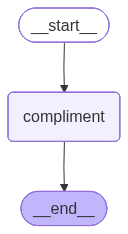

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
result = app.invoke({"name": "Bob"})
result["name"]

'Bob, You are doing an amazing job learning how to use langraph!'

# Agent 2

In [6]:
class AgentState(TypedDict):
    name: str
    values: list[int]
    operation: str
    result: int

In [7]:
def perform_operation(state: AgentState) -> AgentState:
    if state["operation"] == "+":
        state["result"] = sum(state["values"])
    elif state["operation"] == "*":
        product = 1
        for value in state["values"]:
            product *= value
        state["result"] = product
    return state

In [8]:
graph = StateGraph(AgentState)

graph.add_node("perform_operation", perform_operation)
graph.set_entry_point("perform_operation")  
graph.set_finish_point("perform_operation")

app = graph.compile()

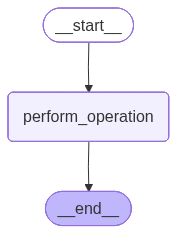

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
result = app.invoke({"name": "Jack Sparrow", "values": [1, 2, 3, 4], "operation": "*"})
result

{'name': 'Jack Sparrow',
 'values': [1, 2, 3, 4],
 'operation': '*',
 'result': 24}

# Agent 3

In [11]:
class Agent(TypedDict):
    name: str
    age: int
    skills: list[str]
    result: str

In [12]:
def first_node(state: Agent) -> Agent:
    state["result"] = state["result"] + "Hi " + state["name"]
    return state

def second_node(state: Agent) -> Agent:
    state["result"] = state["result"] + ", You are " + str(state['age']) + " years old"
    return state

def third_node(state: Agent) -> Agent:
    skills = ", ".join(state["skills"])
    state["result"] += f", and you have skills in: {skills}"
    return state

In [13]:
graph = StateGraph(Agent)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")

graph.set_entry_point("first_node")
graph.set_finish_point("third_node")

app = graph.compile()

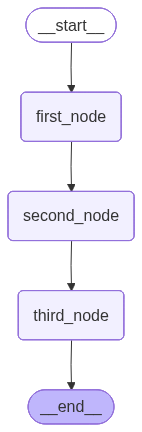

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({
    "name": "Linda", 
    "age": 30, 
    "skills": ["Python", "Data Science"],
    "result": ""  # Add this to initialize the field
})

In [16]:
result

{'name': 'Linda',
 'age': 30,
 'skills': ['Python', 'Data Science'],
 'result': 'Hi Linda, You are 30 years old, and you have skills in: Python, Data Science'}

# Agent 4

In [17]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    number3: int
    number4: int
    operation2: str
    finalNumber: int
    finalNumber2: int

In [18]:
def add1(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtract1(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def add2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtract2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

def router1(state: AgentState) -> AgentState:
    return state["operation1"]

def router2(state: AgentState) -> AgentState:
    return state["operation2"]

In [19]:
from langgraph.graph import START, END

graph = StateGraph(AgentState)

graph.add_node("router1", lambda state: state)
graph.add_node("router2", lambda state: state)
graph.add_node("add_node", add1)
graph.add_node("add_node2", add2)
graph.add_node("subtract_node", subtract1)
graph.add_node("subtract_node2", subtract2)

graph.add_edge(START, "router1")
graph.add_conditional_edges("router1", router1, {
    "+": "add_node",
    "-": "subtract_node"
})

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges("router2", router2, {
    "+": "add_node2",
    "-": "subtract_node2"
})

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

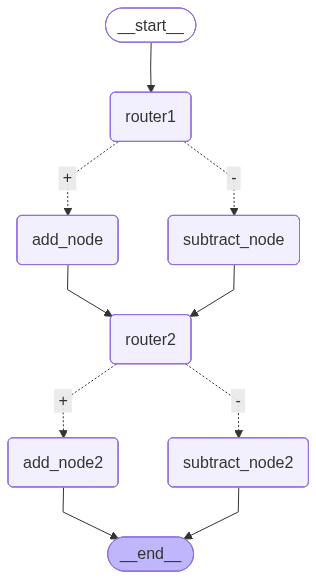

In [20]:
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({
    "number1": 10,
    "operation1": "+",
    "number2": 5,
    "operation2": "-",
    "number3": 20,
    "number4": 8,
    "finalNumber": 0,
    "finalNumber2": 0
})

In [22]:
result

{'number1': 10,
 'operation1': '+',
 'number2': 5,
 'number3': 20,
 'number4': 8,
 'operation2': '-',
 'finalNumber': 15,
 'finalNumber2': 12}

# Agent 5

In [23]:
class agentState(TypedDict):
    playerName: str
    guess: list[int]
    attempts: int
    lowerBound: int
    upperBound: int
    hint: str
    targetNumber: int

In [24]:
import random


def setup(state: agentState) -> agentState:
    state['targetNumber'] = random.randint(state['lowerBound'], state['upperBound'])
    return state

def guess(state: agentState) -> agentState:
    guesses = state.get("guess", [])
    lower = state["lowerBound"]
    upper = state["upperBound"]

    # Update bounds based on the last hint
    if guesses:  # only apply hint if we've guessed before
        last = guesses[-1]
        hint_val = state.get("hint", "")

        if hint_val == "higher":        # last guess was too low, go higher
            lower = last + 1
        elif hint_val == "lower":       # last guess was too high, go lower
            upper = last - 1

    # Safety check after updating bounds
    if lower > upper:
        return {**state, "hint": "correct"}

    new_guess = random.randint(lower, upper)

    return {
        **state,
        "guess": guesses + [new_guess],
        "attempts": state["attempts"] + 1,
        "lowerBound": lower,        # ✅ persist updated bounds
        "upperBound": upper         # ✅ persist updated bounds
    }

def hint(state: agentState) -> agentState:
    last = state["guess"][-1]
    target = state["targetNumber"]

    if last < target:
        h = "higher"   # ✅ guess too low → need to go higher
    elif last > target:
        h = "lower"    # ✅ guess too high → need to go lower
    else:
        h = "correct"

    return {**state, "hint": h}

def should_continue(state: agentState):
    if state['hint'] == "correct":
        return "end"
    elif state['attempts'] >= 7:
        return "end"
    else:
        return "continue"


In [25]:
graph = StateGraph(agentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint", hint)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges("hint", should_continue, {
    "continue": "guess",
    "end": END
})

app = graph.compile()

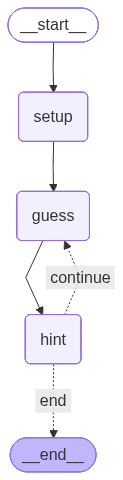

In [26]:
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
result = app.invoke({
    "playerName": "Student",
    "guess": [],
    "attempts": 0,
    "lowerBound": 1,
    "upperBound": 20,
    "hint": "",
    "targetNumber": 0
})


In [28]:
result

{'playerName': 'Student',
 'guess': [2, 6, 19, 9, 13, 12, 10],
 'attempts': 7,
 'lowerBound': 10,
 'upperBound': 11,
 'hint': 'correct',
 'targetNumber': 10}

# AI Agent 1

ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it